Vamos a realizar un arbol de decision con scikit-learn


In [10]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont

In [11]:
artist_billboard = pd.read_csv('artists_billboard_fix3.csv')
artist_billboard.shape


(635, 11)

In [12]:
artist_billboard.head()

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191.0,0,1975.0
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368.0,0,1989.0
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223.0,1,1993.0
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206.0,0,1989.0
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232.0,0,0.0


In [13]:
artist_billboard.groupby('top').size()

top
0    494
1    141
dtype: int64

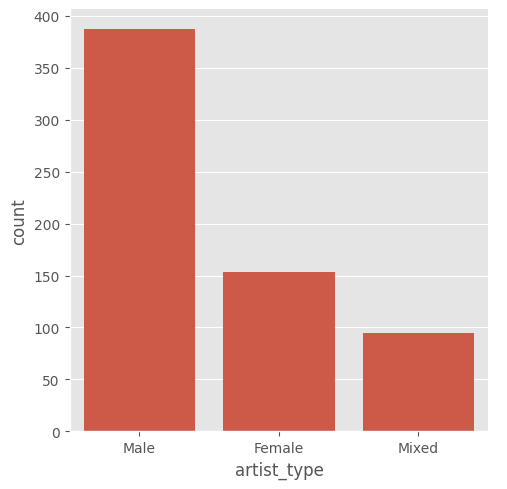

In [14]:
sb.catplot(x='artist_type', data=artist_billboard, kind='count')

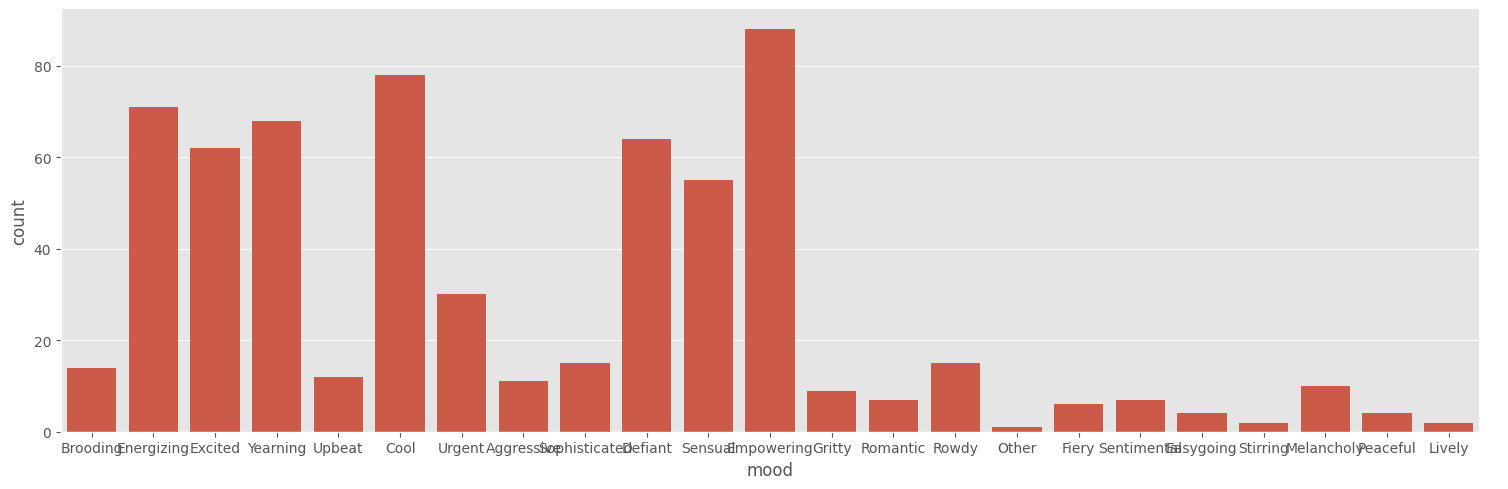

In [15]:
sb.catplot(x = 'mood', data = artist_billboard, kind = 'count', aspect=3)

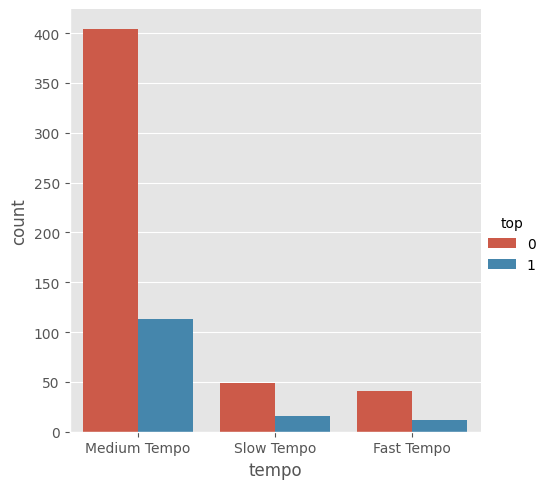

In [16]:
sb.catplot(x = 'tempo', data = artist_billboard, hue = 'top', kind = 'count')

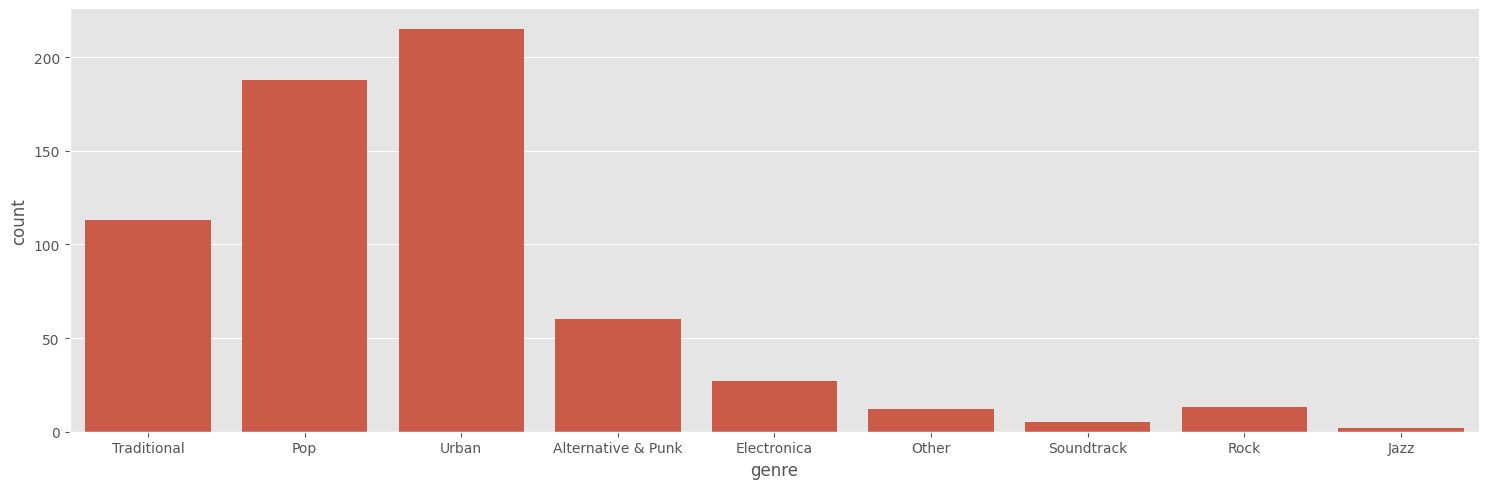

In [17]:
sb.catplot(x = 'genre', data = artist_billboard, kind = 'count', aspect=3)

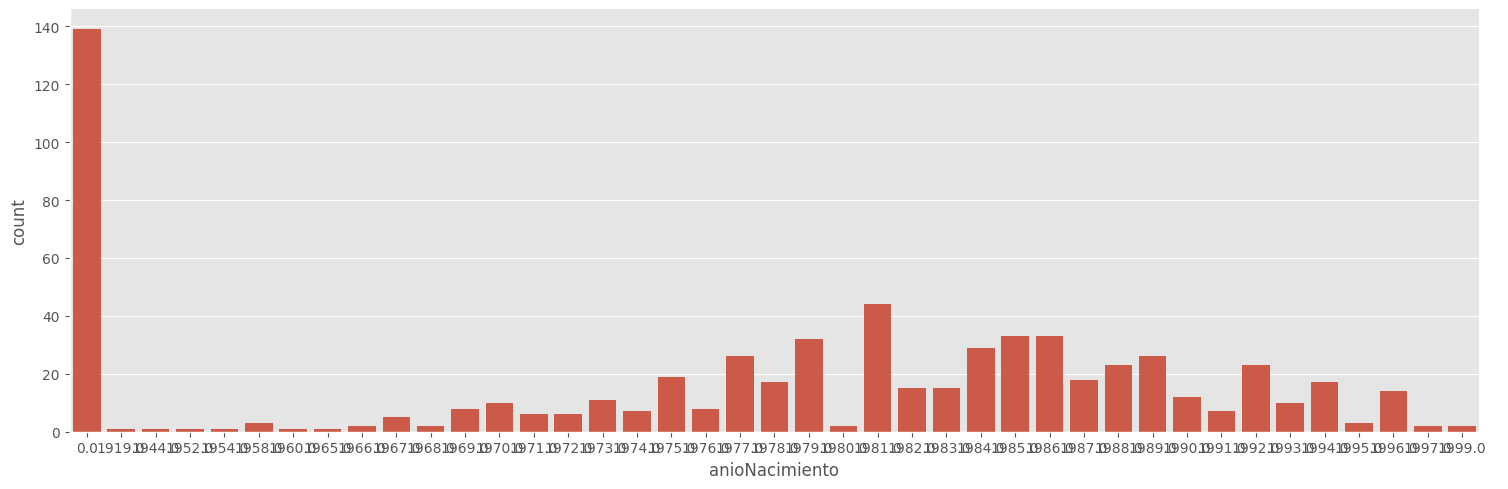

In [18]:
sb.catplot(x = 'anioNacimiento', data = artist_billboard, kind = 'count', aspect=3)

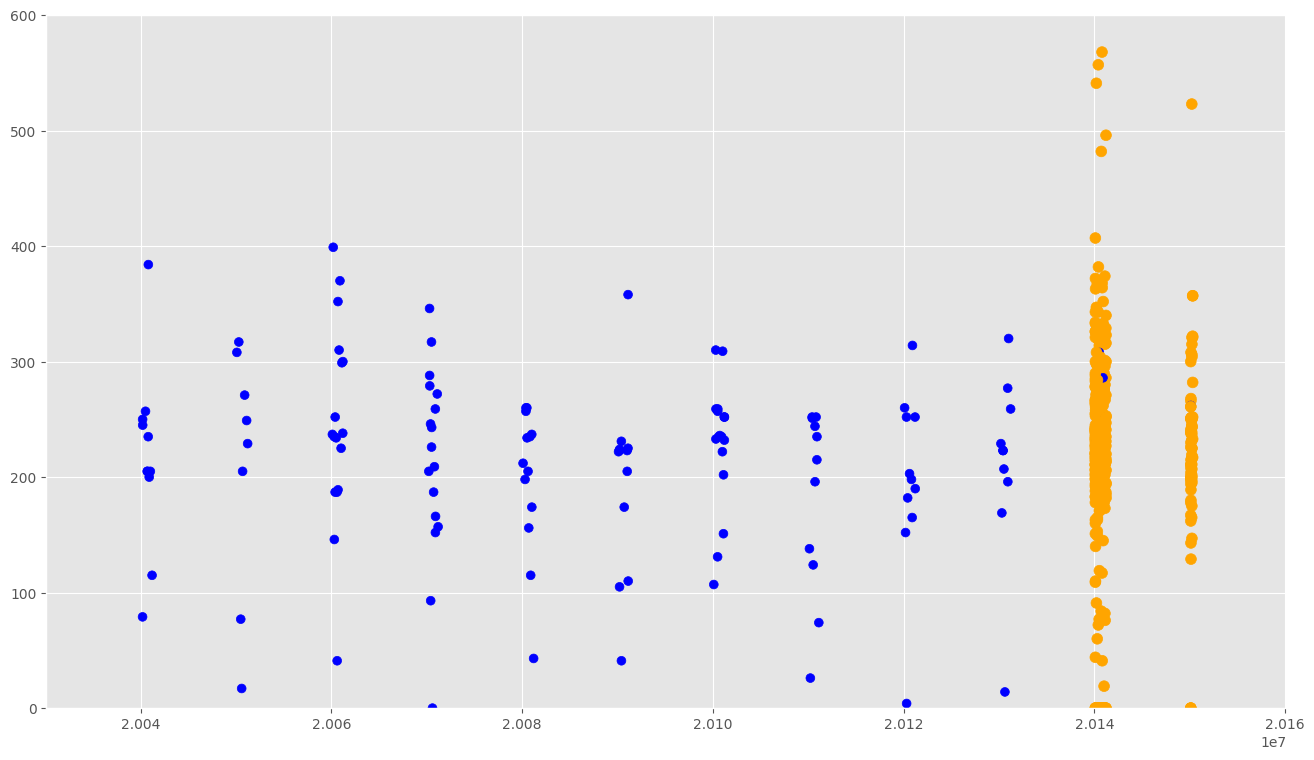

In [19]:
f1 = artist_billboard['chart_date'].values
f2 = artist_billboard['durationSeg'].values

colores = ['orange', 'blue']
tamanios = [60, 40]

asignar = []
asignar2 = []
for index, row in artist_billboard.iterrows():
    asignar.append(colores[row['top']])
    asignar2.append(tamanios[row['top']])

plt.scatter(f1, f2, c = asignar, s = asignar2)
plt.axis([20030101, 20160101, 0, 600])
plt.show()


In [20]:
def edad_fix(anio):
    if anio == 0:
        return None
    return anio

artist_billboard['anioNacimiento'] = artist_billboard.apply(lambda x: edad_fix(x['anioNacimiento']), axis = 1);

In [21]:
def calcula_edad(anio, cuando):
    cad = str(cuando)
    momento = cad[:4]
    if anio == 0.0:
        return None
    return int(momento) - anio

artist_billboard['edad_en_billboard'] = artist_billboard.apply(lambda x: calcula_edad(x['anioNacimiento'], x['chart_date']), axis = 1);

In [22]:
age_avg = artist_billboard['edad_en_billboard'].mean()
age_std = artist_billboard['edad_en_billboard'].std()
age_null_count = artist_billboard['edad_en_billboard'].isnull().sum()
age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size = age_null_count)

conValoresNulos = np.isnan(artist_billboard['edad_en_billboard'])

artist_billboard.loc[np.isnan(artist_billboard['edad_en_billboard']), 'edad_en_billboard'] = age_null_random_list
artist_billboard['edad_en_billboard'] = artist_billboard['edad_en_billboard'].astype(int)
print('Edad promedio: ' + str(age_avg))
print('Desvio std Edad: '+ str(age_std))
print('Intervalo para asignar edad aleatoria: '+str(int(age_avg - age_std)) + ' a ' + str(int(age_avg+age_std)))

Edad promedio: 30.10282258064516
Desvio std Edad: 8.40078832861513
Intervalo para asignar edad aleatoria: 21 a 38


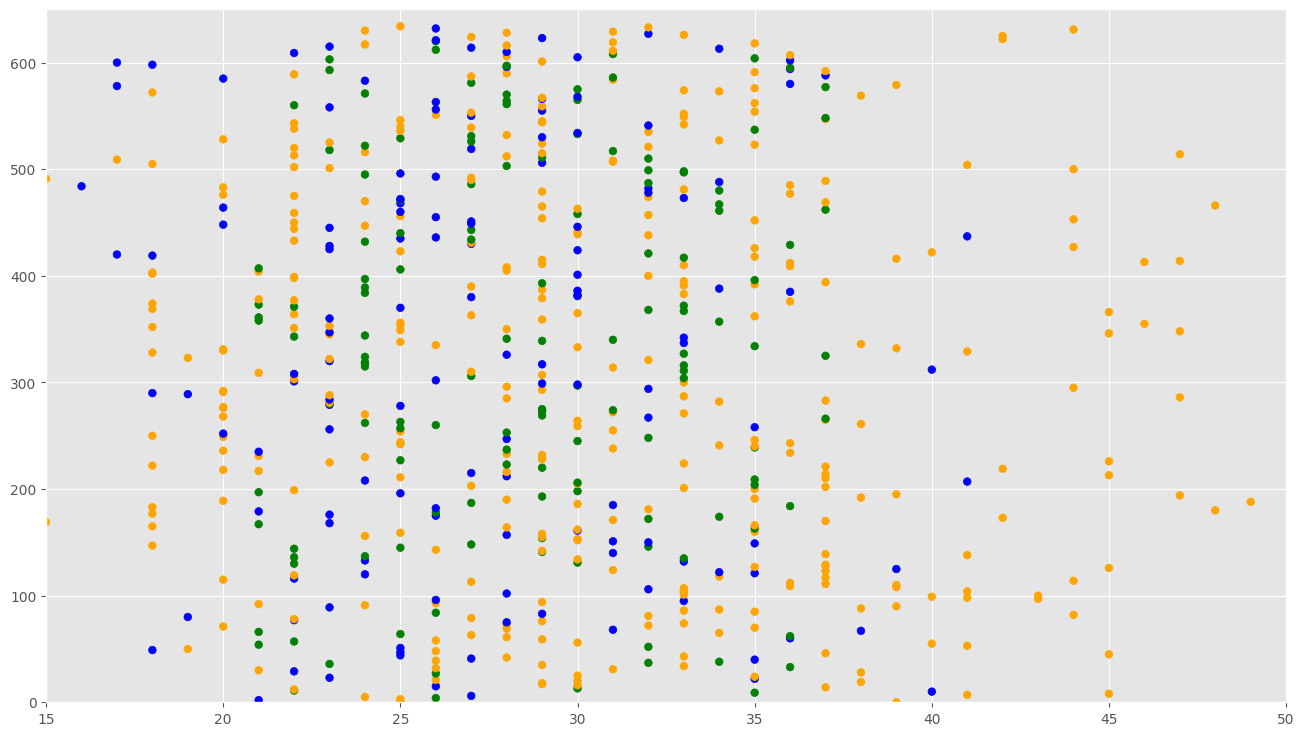

In [23]:
f1 = artist_billboard['edad_en_billboard'].values
f2 = artist_billboard.index

colores = ['orange', 'blue', 'green']

asignar = []

for index, row in artist_billboard.iterrows():
    if(conValoresNulos[index]):
        asignar.append(colores[2])
    else:
        asignar.append(colores[row['top']])

plt.scatter(f1, f2, c = asignar, s = 30)
plt.axis([15, 50, 0, 650])
plt.show()

In [24]:
artist_billboard['moodEncoded'] = artist_billboard['mood'].map( {'Energizing': 6, 'Empowering': 6, 'Cool': 5, 'Yearning': 4, 'Excited': 5, 'Defiant': 3, 'Sensual': 2, 'Gritty': 3, 'Sophisticated': 4, 'Agressive' : 4, 'Fiery': 4, 'Urgent': 3, 'Rowdy': 4, 'Sentimental': 4, 'Easygoing': 1, 'Melancholy': 4, 'Romantic': 2, 'Paceful': 1, 'Brooding': 4, 'Upbeat': 5, 'Stirring': 5, 'Lively': 5, 'Other':0, '': 0}).fillna(0).astype(int)

artist_billboard['tempoEncoded'] = artist_billboard['tempo'].map({'Fast Tempo': 0, 'Medium Tempo': 2, 'Slow Tempo': 1, '': 0}).fillna(0).astype(int)
artist_billboard['genreEncoded'] = artist_billboard['genre'].map( {'Urban': 4, 'Pop': 3, 'Traditional': 2, 'Alternative & Punk': 1, 'Electronica': 1, 'Rock': 1, 'Soundtrack': 0, 'Jazz': 0, 'Other': 0, '': 0})

artist_billboard['artist_typeEncoded'] = artist_billboard['artist_type'].map({'Female': 2, 'Male': 3, 'Mixed': 1, '': 0}).fillna(0).astype(int)
artist_billboard.loc[ artist_billboard['edad_en_billboard'] <= 21, 'edadEncoded'] = 0
artist_billboard.loc[ artist_billboard['edad_en_billboard'] > 21 & (artist_billboard['edad_en_billboard'] <= 26), 'edadEncoded'] = 1
artist_billboard.loc[ artist_billboard['edad_en_billboard'] > 26 & (artist_billboard['edad_en_billboard'] <= 30), 'edadEncoded'] = 2
artist_billboard.loc[ artist_billboard['edad_en_billboard'] > 30 & (artist_billboard['edad_en_billboard'] <= 40), 'edadEncoded'] = 3
artist_billboard.loc[ artist_billboard['edad_en_billboard'] > 40, 'edadEncoded'] = 4

artist_billboard.loc[ artist_billboard['durationSeg'] <= 150, 'durationEncoded'] = 0
artist_billboard.loc[(artist_billboard['durationSeg'] > 150) & (artist_billboard['durationSeg'] <= 180), 'durationEncoded'] = 1
artist_billboard.loc[(artist_billboard['durationSeg'] > 180) & (artist_billboard['durationSeg'] <= 210), 'durationEncoded'] = 2
artist_billboard.loc[(artist_billboard['durationSeg'] > 210) & (artist_billboard['durationSeg'] <= 240), 'durationEncoded'] = 3
artist_billboard.loc[(artist_billboard['durationSeg'] > 240) & (artist_billboard['durationSeg'] <= 270), 'durationEncoded'] = 4
artist_billboard.loc[(artist_billboard['durationSeg'] > 270) & (artist_billboard['durationSeg'] <= 300), 'durationEncoded'] = 5
artist_billboard.loc[(artist_billboard['durationSeg'] > 300), 'durationEncoded'] = 6


In [25]:
drop_elements = ['id', 'title', 'artist', 'mood', 'tempo', 'genre', 'artist_type', 'chart_date', 'anioNacimiento', 'durationSeg', 'edad_en_billboard']
artists_encoded = artist_billboard.drop(drop_elements, axis = 1)

In [26]:
artists_encoded[['moodEncoded', 'top']].groupby(['moodEncoded'], as_index = False).agg(['mean', 'count', 'sum'])

moodEncoded       top          
                   mean count sum
0           0  0.187500    16   3
1           1  0.000000     4   0
2           2  0.274194    62  17
3           3  0.145631   103  15
4           4  0.125926   135  17
5           5  0.294872   156  46
6           6  0.270440   159  43

In [27]:
artists_encoded[['artist_typeEncoded', 'top']].groupby(['artist_typeEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

artist_typeEncoded       top          
                          mean count sum
0                  1  0.305263    95  29
1                  2  0.320261   153  49
2                  3  0.162791   387  63

In [28]:
artists_encoded[['genreEncoded', 'top']].groupby(['genreEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

genreEncoded       top          
                    mean count sum
0            0  0.105263    19   2
1            1  0.070000   100   7
2            2  0.008850   113   1
3            3  0.319149   188  60
4            4  0.330233   215  71

In [29]:
artists_encoded[['tempoEncoded', 'top']].groupby(['tempoEncoded'], as_index=False).agg(['mean', 'count', 'sum'])

tempoEncoded       top           
                    mean count  sum
0            0  0.226415    53   12
1            1  0.246154    65   16
2            2  0.218569   517  113

In [30]:
artists_encoded[['durationEncoded', 'top']].groupby(['durationEncoded'], as_index=False).agg(['mean', 'count', 'sum'])


durationEncoded       top          
                       mean count sum
0             0.0  0.295775    71  21
1             1.0  0.333333    30  10
2             2.0  0.212963   108  23
3             3.0  0.202381   168  34
4             4.0  0.232143   112  26
5             5.0  0.145455    55   8
6             6.0  0.208791    91  19

In [31]:
artists_encoded[['edadEncoded', 'top']].groupby(['edadEncoded'], as_index=False).agg(['mean', 'count', 'sum'])


edadEncoded       top           
                   mean count  sum
0         3.0  0.236395   588  139
1         4.0  0.042553    47    2

In [32]:
cv = KFold(n_splits=10)
accuracies = list()
max_attributes = len(list(artists_encoded))
depth_range = range(1, max_attributes + 1)

for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(criterion='entropy', min_samples_split= 20, min_samples_leaf= 5, max_depth= depth, class_weight= {1:3.5})

    for train_fold, valid_fold in cv.split(artists_encoded):
        f_train = artists_encoded.loc[train_fold]
        f_valid = artists_encoded.loc[valid_fold]

        model = tree_model.fit(X = f_train.drop(['top'], axis = 1), y = f_train['top'])
        valid_acc = model.score(X = f_valid.drop(['top'], axis = 1), y = f_valid['top'])

        fold_accuracy.append(valid_acc)

    avg = sum(fold_accuracy)/len(fold_accuracy)
    accuracies.append(avg)

df = pd.DataFrame({'Max Depth': depth_range, 'Average Accuracy': accuracies})
df = df[['Max Depth', 'Average Accuracy']]
print(df.to_string(index = False))

 Max Depth  Average Accuracy
         1          0.556101
         2          0.556126
         3          0.562450
         4          0.620685
         5          0.614261
         6          0.625273
         7          0.617361


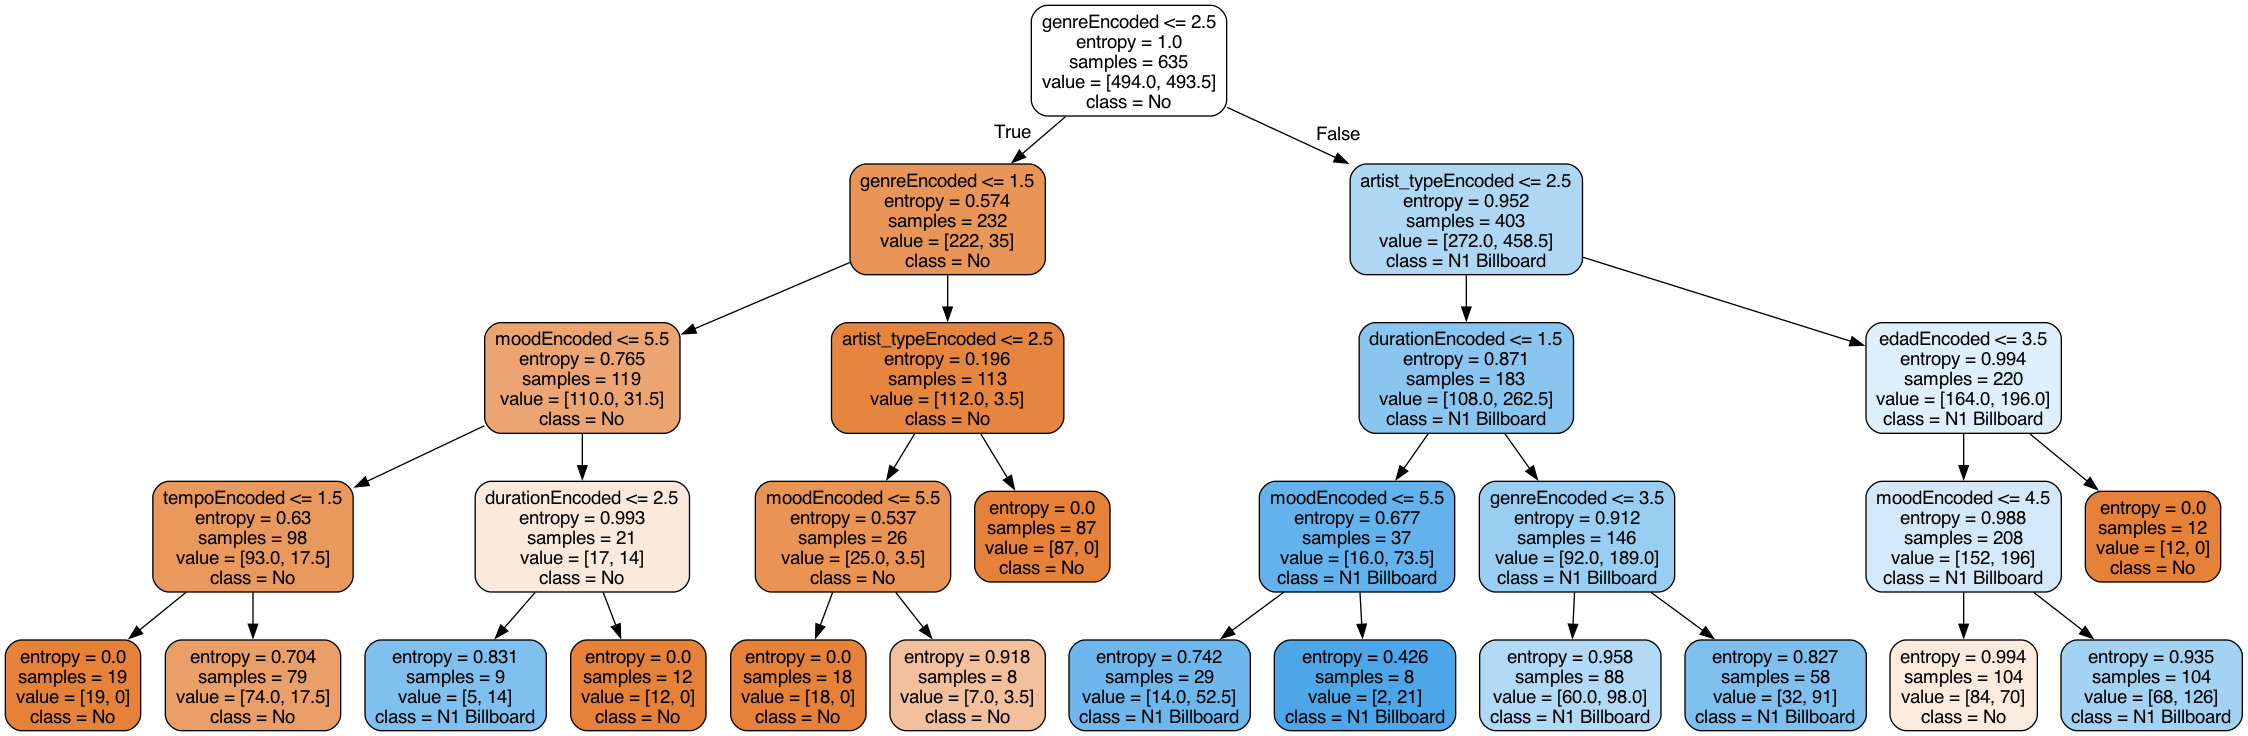

In [33]:
y_train = artists_encoded['top']
x_train = artists_encoded.drop(['top'], axis = 1).values

decision_tree = tree.DecisionTreeClassifier(criterion='entropy', min_samples_split = 20 ,min_samples_leaf = 5, max_depth = 4, class_weight = {1:3.5})
decision_tree.fit(x_train, y_train)

with open(r'tree1.dot', 'w') as f:
    f = tree.export_graphviz(decision_tree, out_file = f, max_depth = 7, impurity = True, feature_names = list(artists_encoded.drop(['top'], axis = 1)), class_names = ['No', 'N1 Billboard'], rounded = True, filled = True)

check_call(['dot', '-Tpng', r'tree1.dot', '-o', r'tree1.png'])
PImage('tree1.png')


In [34]:
acc_decision_tree = round(decision_tree.score(x_train, y_train) * 100, 2)
print(acc_decision_tree)

67.4


In [36]:
x_test = pd.DataFrame(columns = ('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded', 'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_test.loc[0] = (1, 5, 2, 4, 1, 0, 3)
y_pred = decision_tree.predict(x_test.drop(['top'], axis = 1))[0]
print('Prediccion: ' + str(y_pred))
y_proba = decision_tree.predict_proba(x_test.drop(['top'], axis = 1))
print('Probabilidad de acierto: ' + str(round(y_proba[0][y_pred] * 100, 2)) + '%')

Prediccion: 1
Probabilidad de acierto: 73.98%


/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [39]:
x_test = pd.DataFrame(columns = ('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded', 'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_test.loc[0] = (0, 4, 2, 1, 3, 2, 3)
y_pred = decision_tree.predict(x_test.drop(['top'], axis = 1))[0]
print('Prediccion: ' + str(y_pred))
y_proba = decision_tree.predict_proba(x_test.drop(['top'], axis = 1))
print('Probabilidad de acierto: ' + str(round(y_proba[0][y_pred] * 100, 2)) + '%')

Prediccion: 0
Probabilidad de acierto: 80.87%


/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
